In [13]:
# import tensorflow as tf
# import numpy as np
# import pandas as pd
# import os
# from tensorflow.keras.layers import Rescaling

import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

Load the training and testing data, rescale all pixels to be float vals within 0-1

In [59]:
# data_dir = '/kaggle/input/cifake-real-and-ai-generated-synthetic-images'
import os
import pandas as pd

data_dir = './archive'

# Define train and test directories
training_directory = os.path.join(data_dir, 'train')
testing_directory = os.path.join(data_dir, 'test')

print(training_directory)


# Get train images
train_real_images = [os.path.join(training_directory, 'REAL', img) for img in os.listdir(os.path.join(training_directory, 'REAL'))]
train_fake_images = [os.path.join(training_directory, 'FAKE', img) for img in os.listdir(os.path.join(training_directory, 'FAKE'))]

# Get test images
test_real_images = [os.path.join(testing_directory, 'REAL', img) for img in os.listdir(os.path.join(testing_directory, 'REAL'))]
test_fake_images = [os.path.join(testing_directory, 'FAKE', img) for img in os.listdir(os.path.join(testing_directory, 'FAKE'))]


# print(test_real_images[0])
# (0, 1) = (fake, real)

real_df = pd.DataFrame({'image_path': train_real_images + test_real_images,
                        'label': [1]*len(train_real_images) + [1]*len(test_real_images)}) ##60 thousand real, 0 fake

fake_df = pd.DataFrame({'image_path': train_fake_images + test_fake_images,
                        'label': [0]*len(train_fake_images) + [0]*len(test_fake_images)}) #0 real, 60 thousand fake

# real_df.head(), fake_df.head()


# Sample 80% of the rows from each DataFrame
rTrain = real_df.sample(frac=0.8, replace=False)
fTrain = fake_df.sample(frac=0.8, replace=False)

train_df = pd.concat([rTrain, fTrain])

#drops sampled from DFs
real_df = real_df.drop(rTrain.index)
fake_df = fake_df.drop(fTrain.index)

print(len(train_df)) #96,000

test_df = pd.concat([real_df, fake_df])
print(len(test_df)) ## 24,000


# print(sum(fake_df['label'] == 0))

./archive/train
96000
24000


Now have the testing and training sets of images, need to convert images into numpy arrays to resize and greyscale them.

num of images = 96000


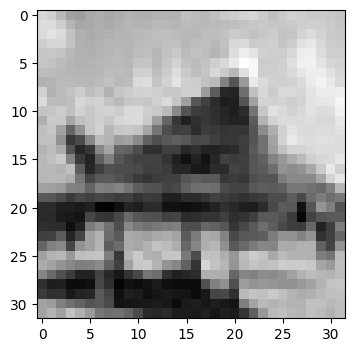

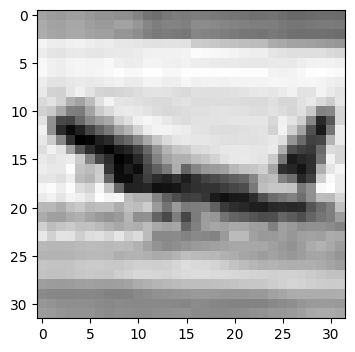

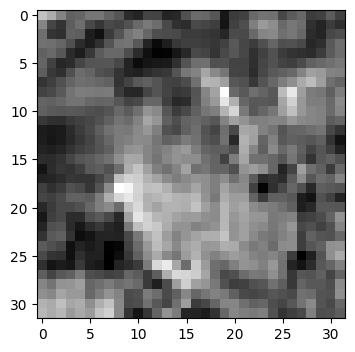

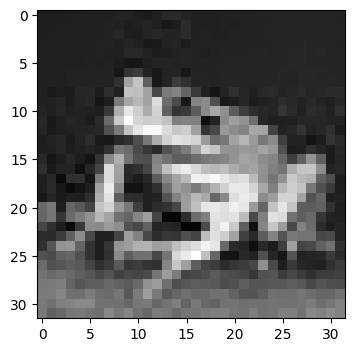

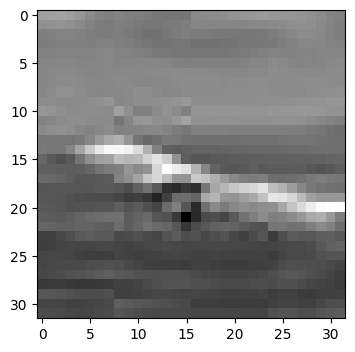

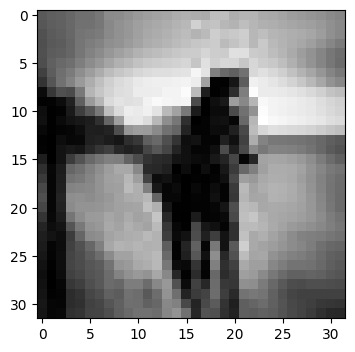

(96000, 1024)


In [80]:
import matplotlib.pyplot as plt
from PIL import Image
# test_df.head()

imgNum = 0
images = []
print(f"num of images = {len(train_df)}")
for filename in train_df["image_path"]:
    # print(filename)
    
    imgNum += 1
    image = plt.imread(filename)
#     img_path = os.path.join("./data/faces", filename)
    # image = plt.imread(filename)
    image = np.dot(
        image[..., :3], [0.299, 0.587, 0.114] )  #From HW3: convert 3D RGB array into 2D grayscale array
    if ((imgNum % 15000) == 0): ## arbitrarily set to not show every image
        fig = plt.figure(figsize=(4, 4))
        plt.imshow(image, cmap="gray")
        plt.show()
    images.append(image.flatten())  # Flatten into a 1D vector

faces = np.array(images)
print(np.shape(faces))





START RUNNING PCA FROM HW IMPLEMENTATION

In [ ]:
import numpy as np
rowMeans = np.mean(images, axis=0)
centered_images = images - rowMeans # center
U, S, V = np.linalg.svd(centered_images, full_matrices=False)

print(f"U dims =  {np.shape(U)}")
print(f"S dims = {np.shape(S)}")
print(f"V dims = {np.shape(V)}")

# there are more steps but Im stopping here for now